# EEG Data Preprocessing and Wrangling for Seizure Prediction

## Project Context
This notebook prepares EEG recordings from the CHB-MIT and Siena datasets for downstream seizure prediction modeling.
At this milestone, one EDF file per dataset is used to validate preprocessing and feature-engineering choices before scaling to all available recordings.

## Section 1: Preprocessing
Objective: standardize heterogeneous EEG recordings into a comparable signal representation suitable for cross-dataset learning.

### 1.1 Environment Setup, Imports, and Data Paths
This step installs and imports the core scientific Python dependencies required for EEG signal processing, feature extraction, and visualization.
It then defines the EDF file paths used throughout the preprocessing workflow.

In [1]:
# Run once per environment to install required packages for this notebook
# This works in Colab and in a fresh local Jupyter kernel.
%pip install -q numpy pandas scipy mne seaborn matplotlib

### 1.1a Dataset Setup for Local and Colab Runs
Before running the next cell, make sure the dataset root directly contains both `chbmit/` and `siena/`.

Required structure:
```text
<dataset root>/
  chbmit/chb01/chb01_01.edf
  siena/pn00/PN00-1.edf
```

Local execution works when the dataset is stored either in `eegStatic/data/` inside this repository or in a separate top-level `data/` directory that contains `chbmit/` and `siena/`.

Colab execution works when the dataset is uploaded into `/content/data/` or `/content/eegStatic/data/`, stored anywhere in mounted Google Drive where the expected EDF files exist, or pointed to explicitly with `EEG_DATA_ROOT`.

`EEG_DATA_ROOT` must point to the folder that directly contains `chbmit/` and `siena/`, not to one of those subfolders.

Example for Colab with Google Drive:
```python
from google.colab import drive
import os

drive.mount("/content/drive")
os.environ["EEG_DATA_ROOT"] = "/content/drive/MyDrive/path/to/eegStatic/data"
```

If you mount Drive or change `EEG_DATA_ROOT`, rerun the next cell so the notebook can resolve the dataset paths again.

The notebook first checks common local and Colab locations and then falls back to a recursive search of mounted Google Drive for the required EDF files.


In [2]:
from pathlib import Path
import os

import mne
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mne.set_log_level("WARNING")

CHB_RELATIVE_PATH = Path("chbmit/chb01/chb01_01.edf")
SIENA_RELATIVE_PATH = Path("siena/pn00/PN00-1.edf")


def has_expected_files(root):
    return (root / CHB_RELATIVE_PATH).exists() and (root / SIENA_RELATIVE_PATH).exists()


def infer_root_from_match(file_path, marker_dir):
    parts = file_path.parts

    if marker_dir not in parts:
        return None

    marker_index = parts.index(marker_dir)

    if marker_index == 0:
        return Path(file_path.anchor)

    return Path(*parts[:marker_index])


def candidate_roots():
    cwd = Path.cwd()
    candidates = []

    env_override = os.environ.get("EEG_DATA_ROOT")
    if env_override:
        candidates.append(Path(env_override).expanduser())

    for candidate in [cwd, *cwd.parents]:
        candidates.extend(
            [
                candidate / "eegStatic" / "data",
                candidate / "data",
            ]
        )

    candidates.extend(
        [
            Path("/content/eegStatic/data"),
            Path("/content/data"),
            Path("/content/drive/MyDrive/eegStatic/data"),
            Path("/content/drive/MyDrive/data"),
            Path("/content/drive/MyDrive/Colab Notebooks/eegStatic/data"),
            Path("/content/drive/MyDrive/Colab Notebooks/data"),
        ]
    )

    return candidates


def recursive_drive_candidates():
    candidates = []
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/Shareddrives"),
    ]

    for search_root in search_roots:
        if not search_root.exists():
            continue

        for chb_match in search_root.rglob(CHB_RELATIVE_PATH.name):
            inferred_root = infer_root_from_match(chb_match, "chbmit")
            if inferred_root is not None:
                candidates.append(inferred_root)

        for siena_match in search_root.rglob(SIENA_RELATIVE_PATH.name):
            inferred_root = infer_root_from_match(siena_match, "siena")
            if inferred_root is not None:
                candidates.append(inferred_root)

    return candidates


def find_dataset_root():
    seen = set()
    checked = []

    for candidate in candidate_roots():
        candidate = candidate.expanduser()
        key = str(candidate)

        if key in seen:
            continue

        seen.add(key)
        checked.append(candidate)

        if has_expected_files(candidate):
            return candidate.resolve(), checked

    for candidate in recursive_drive_candidates():
        candidate = candidate.expanduser()
        key = str(candidate)

        if key in seen:
            continue

        seen.add(key)
        checked.append(candidate)

        if has_expected_files(candidate):
            return candidate.resolve(), checked

    return None, checked


def running_in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


print("Current working directory:", Path.cwd())
print("EEG_DATA_ROOT:", os.environ.get("EEG_DATA_ROOT", "<not set>"))

if Path("/content/drive/MyDrive").exists():
    print("Google Drive mount detected at /content/drive/MyDrive")


dataset_root, checked_paths = find_dataset_root()

if dataset_root is None and running_in_colab():
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

    dataset_root, checked_paths = find_dataset_root()

if dataset_root is None:
    checked_display = "\n".join(f" - {path}" for path in checked_paths)
    raise FileNotFoundError(
        "Could not locate the EEG dataset files.\n"
        f"Working directory: {Path.cwd()}\n"
        f"Checked locations:\n{checked_display}\n\n"
        "In Colab, either upload a folder named data/ or eegStatic/data/ to /content, "
        "mount Google Drive and place the dataset there, or set EEG_DATA_ROOT to the folder "
        "that contains chbmit/ and siena/."
    )

# File paths
chb_path = dataset_root / CHB_RELATIVE_PATH
siena_path = dataset_root / SIENA_RELATIVE_PATH

print("Using dataset root:", dataset_root)
print("Verified dataset structure found.")
print("CHB file:", chb_path)
print("Siena file:", siena_path)

Current working directory: /content
EEG_DATA_ROOT: <not set>
Google Drive mount detected at /content/drive/MyDrive
Using dataset root: /content/drive/MyDrive/Colab Notebooks/data/eegStatic/Data
Verified dataset structure found.
CHB file: /content/drive/MyDrive/Colab Notebooks/data/eegStatic/Data/chbmit/chb01/chb01_01.edf
Siena file: /content/drive/MyDrive/Colab Notebooks/data/eegStatic/Data/siena/pn00/PN00-1.edf


### 1.2 Raw EEG Loading and Initial Audit
The EDF recordings are loaded and inspected for sampling rate and channel count.
This initial audit establishes cross-dataset differences that must be harmonized before reliable seizure-related feature comparison.

In [3]:
raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
raw_siena = mne.io.read_raw_edf(siena_path, preload=False, verbose=False)

print("CHB sampling rate:", raw_chb.info["sfreq"])
print("CHB number of channels:", len(raw_chb.ch_names))

print("Siena sampling rate:", raw_siena.info["sfreq"])
print("Siena number of channels:", len(raw_siena.ch_names))

CHB sampling rate: 256.0
CHB number of channels: 23
Siena sampling rate: 512.0
Siena number of channels: 35


/tmp/ipykernel_12386/2310033075.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
/tmp/ipykernel_12386/2310033075.py:1: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
/tmp/ipykernel_12386/2310033075.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_siena = mne.io.read_raw_edf(siena_path, preload=False, verbose=False)
/tmp/ipykernel_12386/2310033075.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_siena = mne.io.read_raw_edf(siena_path, preload=False, verbose=False)
/tmp/ipykernel_12386/2310033075.py:2: RuntimeWarning: Highpass cutoff

### 1.3 Preprocessing Methodology
The preprocessing pipeline removes non-EEG channels, resolves MNE-generated duplicate channel labels, and harmonizes sampling rates across datasets.
A common target sampling frequency of 256 Hz is used to align CHB-MIT and Siena representations for cross-dataset feature comparability.
A band-pass filter (0.5-40 Hz) and 60 Hz notch filter are then applied to reduce artifact and line-noise contamination while preserving clinically relevant EEG rhythms.

In [4]:
def drop_mne_duplicates(raw):
    to_drop = [ch for ch in raw.ch_names if ch.endswith("-1")]
    if to_drop:
        raw.drop_channels(to_drop)


def preprocess_eeg(raw, dataset_name, target_sfreq=256):
    raw = raw.copy()
    raw.load_data()

    # Drop obvious non-EEG channels
    non_eeg_keywords = [
        "EKG",
        "ECG",
        "SPO2",
        "HR",
        "PHOTIC",
        "IBI",
        "BURSTS",
        "SUPPR",
        "MK",
    ]
    drop_now = []

    for ch in raw.ch_names:
        ch_upper = ch.upper()
        if any(word in ch_upper for word in non_eeg_keywords):
            drop_now.append(ch)

    if drop_now:
        raw.drop_channels(drop_now)

    # Drop duplicate channels added by MNE
    drop_mne_duplicates(raw)

    # Resample to a common sampling rate
    if raw.info["sfreq"] != target_sfreq:
        raw.resample(target_sfreq)

    # Set all remaining channels to EEG
    raw.set_channel_types({ch: "eeg" for ch in raw.ch_names})

    # Re-reference Siena only
    if dataset_name.lower() == "siena":
        raw.set_eeg_reference("average", projection=False)

    # Bandpass filter
    raw.filter(l_freq=0.5, h_freq=40.0, verbose=False)

    # Notch filter
    raw.notch_filter(freqs=60, verbose=False)

    return raw

### 1.4 Pipeline Execution and Verification
The preprocessing function is applied to both datasets, and resulting metadata are checked to confirm expected harmonization.
This verification step supports reproducible feature extraction and cross-dataset modeling consistency.

In [5]:
raw_chb_clean = preprocess_eeg(raw_chb, "CHB")
raw_siena_clean = preprocess_eeg(raw_siena, "Siena")

print("CHB cleaned sampling rate:", raw_chb_clean.info["sfreq"])
print("CHB cleaned channels:", len(raw_chb_clean.ch_names))

print("Siena cleaned sampling rate:", raw_siena_clean.info["sfreq"])
print("Siena cleaned channels:", len(raw_siena_clean.ch_names))

CHB cleaned sampling rate: 256.0
CHB cleaned channels: 22
Siena cleaned sampling rate: 256.0
Siena cleaned channels: 31


### 1.5 Epoch Construction via Sliding Windows
Continuous EEG is partitioned into overlapping fixed-length windows to create model-ready analysis units.
The current prototype uses 2-second windows with 1-second overlap, balancing temporal resolution against feature stability.
Overlapping windows improve temporal coverage of transient seizure dynamics while preserving local context.

In [6]:
# Prototype windowing parameters: 2-second windows with 1-second overlap
def make_epochs(raw, duration=2.0, overlap=1.0):
    return mne.make_fixed_length_epochs(
        raw, duration=duration, overlap=overlap, preload=True, verbose=False
    )


epochs_chb = make_epochs(raw_chb_clean, duration=2.0, overlap=1.0)
epochs_siena = make_epochs(raw_siena_clean, duration=2.0, overlap=1.0)

X_chb = epochs_chb.get_data()
X_siena = epochs_siena.get_data()

print("CHB epoch shape:", X_chb.shape)
print("Siena epoch shape:", X_siena.shape)

CHB epoch shape: (244, 22, 512)
Siena epoch shape: (2624, 31, 512)


### 1.6 Time-Domain Feature Extraction
Each epoch is summarized with statistical and energy-based descriptors to capture amplitude dispersion, volatility, and power concentration.
These compact representations are designed to support seizure prediction models that operate on tabular features.

In [7]:
def extract_features(epoch_data, dataset_name, sfreq, duration=2.0):
    rows = []

    for i, epoch in enumerate(epoch_data):
        flat = epoch.flatten()

        row = {
            "dataset": dataset_name,
            "epoch_index": i,
            "epoch_start_sec": i * (duration - 1.0),
            "mean": np.mean(flat),
            "std": np.std(flat),
            "min": np.min(flat),
            "max": np.max(flat),
            "range": np.max(flat) - np.min(flat),
            "energy": np.sum(flat**2),
            "rms": np.sqrt(np.mean(flat**2)),
            "abs_mean": np.mean(np.abs(flat)),
            "channel_count": epoch.shape[0],
            "samples_per_epoch": epoch.shape[1],
            "sampling_rate": sfreq,
        }

        rows.append(row)

    return pd.DataFrame(rows)

### 1.7 Unified Feature Table Assembly
Feature matrices from CHB-MIT and Siena are concatenated into a single analysis table.
A combined table enables shared quality control, wrangling operations, and comparative exploratory analysis.

In [8]:
df_chb = extract_features(X_chb, "CHB", raw_chb_clean.info["sfreq"], duration=2.0)
df_siena = extract_features(
    X_siena, "Siena", raw_siena_clean.info["sfreq"], duration=2.0
)

df_all = pd.concat([df_chb, df_siena], ignore_index=True)

print("Final feature table shape:", df_all.shape)
df_before = df_all.copy()
df_all

Final feature table shape: (2868, 14)


,dataset,epoch_index,epoch_start_sec,mean,std,min,max,range,energy,rms,abs_mean,channel_count,samples_per_epoch,sampling_rate
0,CHB,0,0.0,1.469223e-05,0.000062,-0.000148,0.000324,0.000472,0.000045,0.000063,0.000043,22,512,256.0
1,CHB,1,1.0,-1.200434e-06,0.000031,-0.000171,0.000236,0.000406,0.000011,0.000031,0.000023,22,512,256.0
2,CHB,2,2.0,-8.916804e-07,0.000028,-0.000171,0.000236,0.000406,0.000009,0.000028,0.000020,22,512,256.0
3,CHB,3,3.0,4.274892e-07,0.000025,-0.000128,0.000154,0.000282,0.000007,0.000025,0.000019,22,512,256.0
4,CHB,4,4.0,5.126279e-07,0.000025,-0.000122,0.000130,0.000251,0.000007,0.000025,0.000019,22,512,256.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,Siena,2619,2619.0,-3.278837e-22,0.000070,-0.000279,0.002422,0.002701,0.000079,0.000070,0.000017,31,512,256.0
2864,Siena,2620,2620.0,4.371783e-22,0.000071,-0.000290,0.002422,0.002712,0.000079,0.000071,0.000019,31,512,256.0
2865,Siena,2621,2621.0,4.371783e-22,0.000075,-0.000363,0.002378,0.002741,0.000090,0.000075,0.000027,31,512,256.0
2866,Siena,2622,2622.0,0.000000e+00,0.000075,-0.000363,0.002399,0.002762,0.000090,0.000075,0.000028,31,512,256.0


## Section 2: Data Wrangling
Objective: improve statistical robustness and feature quality before downstream seizure prediction modeling, while retaining clinically meaningful signal variation.

### 2.1 Missing-Value Assessment
Feature completeness is evaluated to ensure that downstream transformations and model fitting are not biased by absent observations.

In [9]:
# Missing Values
print(df_all.isnull().sum())

dataset              0
epoch_index          0
epoch_start_sec      0
mean                 0
std                  0
min                  0
max                  0
range                0
energy               0
rms                  0
abs_mean             0
channel_count        0
samples_per_epoch    0
sampling_rate        0
dtype: int64


### 2.2 Data Type Standardization
Categorical and integer casting is applied to key identifiers to support stable grouping, indexing, and reproducible analysis semantics.
This also prepares metadata fields for downstream model pipelines and evaluation reports.

In [10]:
print(df_all.dtypes)
df_all["dataset"] = df_all["dataset"].astype("category")
df_all["epoch_index"] = df_all["epoch_index"].astype(int)

dataset               object
epoch_index            int64
epoch_start_sec      float64
mean                 float64
std                  float64
min                  float64
max                  float64
range                float64
energy               float64
rms                  float64
abs_mean             float64
channel_count          int64
samples_per_epoch      int64
sampling_rate        float64
dtype: object


### 2.3 Outlier Diagnostics with IQR and Z-Score
Outlier profiles are quantified using two complementary methods: IQR thresholds and Z-score deviation.
Joint inspection helps distinguish distribution-tail behavior from extreme standardized departures in core predictors.

In [11]:
from scipy.stats import zscore

cols = ["mean", "std", "range", "energy", "rms"]

for col in cols:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col, "IQR outliers:", ((df_all[col] < lower) | (df_all[col] > upper)).sum())

    z_vals = np.abs(zscore(df_all[col]))
    print(col, "Z-score outliers:", (z_vals > 3).sum())

mean IQR outliers: 312
mean Z-score outliers: 53
std IQR outliers: 611
std Z-score outliers: 34
range IQR outliers: 443
range Z-score outliers: 135
energy IQR outliers: 656
energy Z-score outliers: 29
rms IQR outliers: 611
rms Z-score outliers: 34


### 2.4 Robust Outlier Handling via IQR Clipping
Rather than removing epochs, feature values are winsorized to IQR bounds.
This preserves sample volume while reducing the influence of extreme amplitudes that may reflect artifacts rather than physiologic dynamics.

In [12]:
for col in cols:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_all[col] = df_all[col].clip(lower, upper)

### 2.5 Derived Feature Engineering
Two additional predictors are introduced: range-to-standard-deviation ratio and per-channel energy normalization.
These derived terms improve comparability across epochs and channel configurations and can enhance seizure-related separability.

In [13]:
df_all["range_to_std"] = df_all["range"] / (df_all["std"] + 1e-8)
df_all["energy_per_channel"] = df_all["energy"] / df_all["channel_count"]

### 2.6 Post-Wrangling Validation
Final dimensionality and missing-value checks verify that wrangling preserved table integrity while enriching the feature set.

In [14]:
print("Before shape:", df_before.shape)
print("After shape:", df_all.shape)
print("Missing after:", df_all.isnull().sum().sum())
df_all

Before shape: (2868, 14)
After shape: (2868, 16)
Missing after: 0


,dataset,epoch_index,epoch_start_sec,mean,std,min,max,range,energy,rms,abs_mean,channel_count,samples_per_epoch,sampling_rate,range_to_std,energy_per_channel
0,CHB,0,0.0,8.743566e-22,0.000062,-0.000148,0.000324,0.002421,0.000053,0.000063,0.000043,22,512,256.0,39.191744,0.000002
1,CHB,1,1.0,-8.743566e-22,0.000059,-0.000171,0.000236,0.002421,0.000053,0.000059,0.000023,22,512,256.0,41.307119,0.000002
2,CHB,2,2.0,-8.743566e-22,0.000059,-0.000171,0.000236,0.002421,0.000053,0.000059,0.000020,22,512,256.0,41.307119,0.000002
3,CHB,3,3.0,8.743566e-22,0.000059,-0.000128,0.000154,0.002421,0.000053,0.000059,0.000019,22,512,256.0,41.307119,0.000002
4,CHB,4,4.0,8.743566e-22,0.000059,-0.000122,0.000130,0.002421,0.000053,0.000059,0.000019,22,512,256.0,41.307119,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,Siena,2619,2619.0,-3.278837e-22,0.000070,-0.000279,0.002422,0.002701,0.000079,0.000070,0.000017,31,512,256.0,38.358377,0.000003
2864,Siena,2620,2620.0,4.371783e-22,0.000071,-0.000290,0.002422,0.002712,0.000079,0.000071,0.000019,31,512,256.0,38.380467,0.000003
2865,Siena,2621,2621.0,4.371783e-22,0.000075,-0.000363,0.002378,0.002741,0.000090,0.000075,0.000027,31,512,256.0,36.451354,0.000003
2866,Siena,2622,2622.0,0.000000e+00,0.000075,-0.000363,0.002399,0.002762,0.000090,0.000075,0.000028,31,512,256.0,36.642029,0.000003


## Section 3: Exploratory Data Analysis (EDA)
Objective: evaluate feature behavior, dataset comparability, and early evidence of separable structure relevant to seizure prediction.
Interpretive emphasis is placed on distribution shape, feature interactions, and temporal behavior across epochs.

### 3.1 Distribution of Standard Deviation
This figure characterizes variability intensity across epochs. Heavy tails or multimodality may indicate intermittent high-variance states relevant to seizure activity.

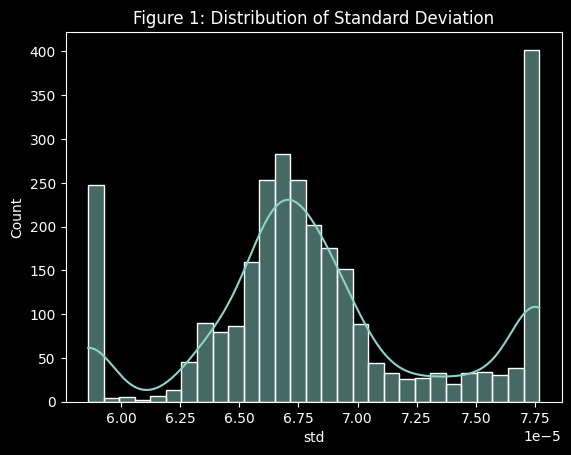

In [15]:
sns.histplot(df_all["std"], kde=True)
plt.title("Figure 1: Distribution of Standard Deviation")
plt.show()

### 3.2 Distribution of Energy
Energy summarizes aggregate signal power per epoch. Elevated tails can reflect transient high-amplitude dynamics often associated with abnormal neural synchronization.

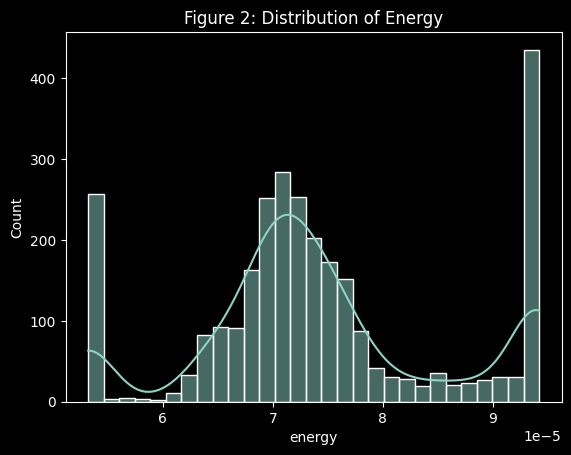

In [16]:
sns.histplot(df_all["energy"], kde=True)
plt.title("Figure 2: Distribution of Energy")
plt.show()

### 3.3 Distribution of RMS
RMS provides an amplitude-sensitive complement to total energy and helps assess whether power concentration patterns are stable across the corpus.

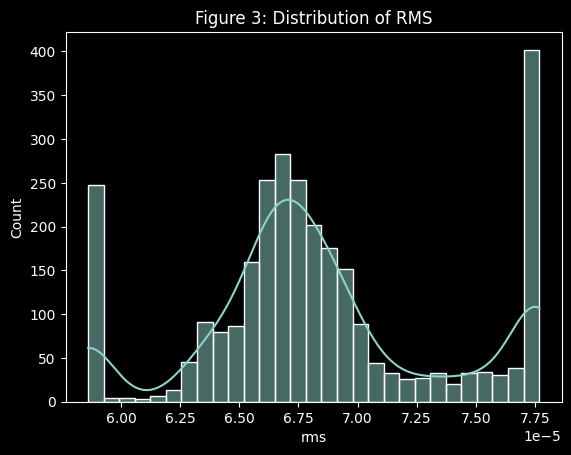

In [17]:
sns.histplot(df_all["rms"], kde=True)
plt.title("Figure 3: Distribution of RMS")
plt.show()

### 3.4 Correlation Structure of Core Features
Correlation analysis identifies potentially redundant predictors and informs feature-selection priorities for classification and calibration workflows.

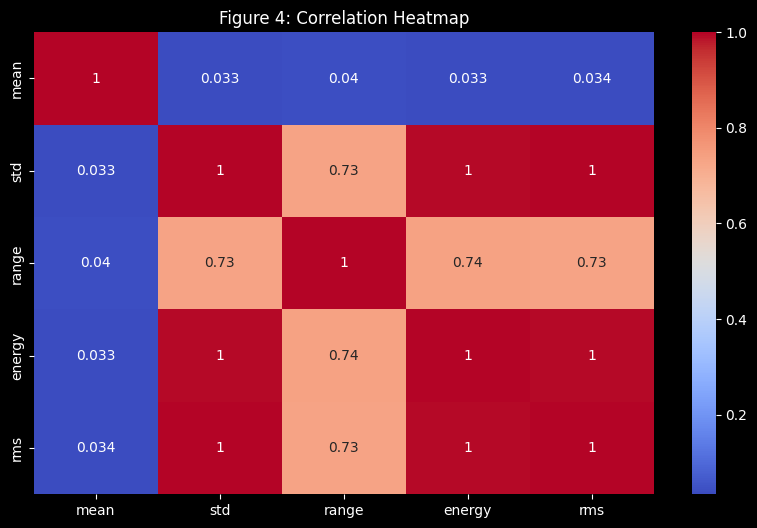

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_all[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Figure 4: Correlation Heatmap")
plt.show()

### 3.5 Epoch Count by Dataset
This plot checks source balance between CHB-MIT and Siena. Strong imbalance can bias model learning and should be considered during splitting and weighting.

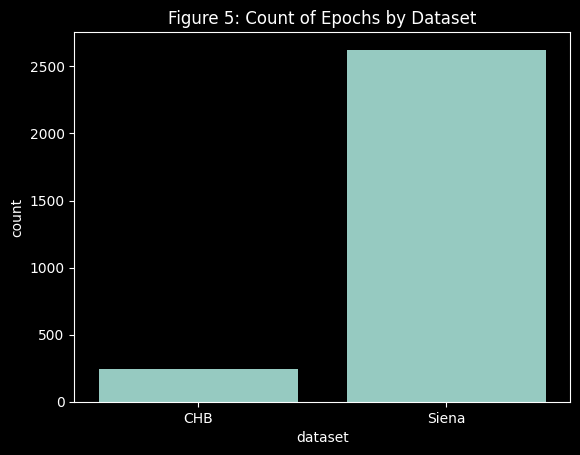

In [19]:
sns.countplot(x="dataset", data=df_all)
plt.title("Figure 5: Count of Epochs by Dataset")
plt.show()

### 3.6 Channel-Count Composition by Dataset
Channel-count differences can introduce domain shift. This visualization supports interpretation of normalization features such as energy per channel.

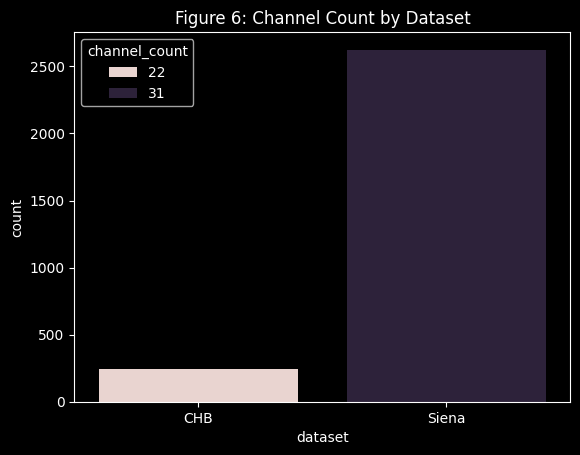

In [20]:
sns.countplot(x="dataset", data=df_all, hue="channel_count")
plt.title("Figure 6: Channel Count by Dataset")
plt.show()

### 3.7 Bivariate Separation: Standard Deviation vs Energy
This scatter view assesses whether datasets exhibit overlapping or distinct feature manifolds, informing transferability of a shared seizure prediction model.

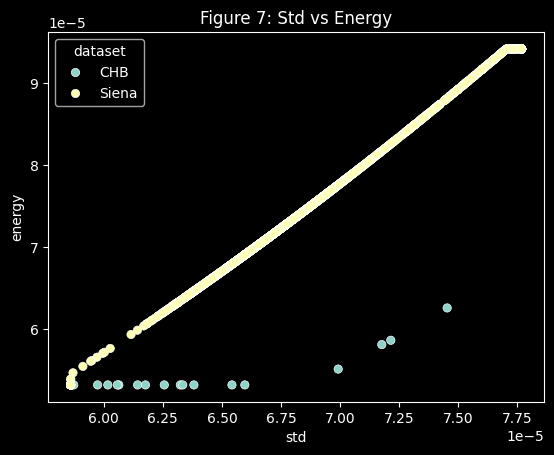

In [21]:
sns.scatterplot(x="std", y="energy", hue="dataset", data=df_all)
plt.title("Figure 7: Std vs Energy")
plt.show()

### 3.8 Temporal Energy Trend Across Epoch Index
Mean energy over epoch index provides a coarse view of non-stationarity. Drift patterns may motivate temporal validation and sequence-aware modeling.

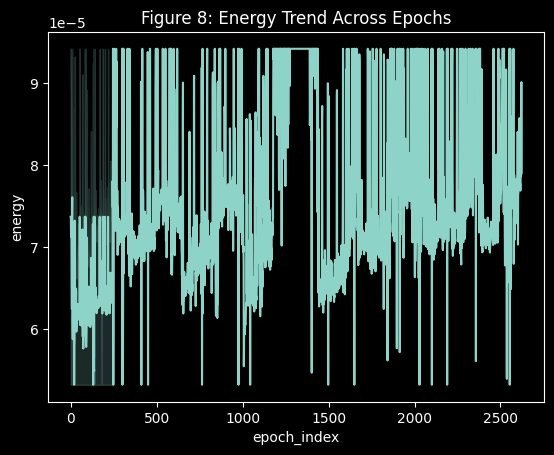

In [22]:
sns.lineplot(x="epoch_index", y="energy", data=df_all, estimator="mean")
plt.title("Figure 8: Energy Trend Across Epochs")
plt.show()

## Limitations and Transition to Modeling
This milestone notebook uses one EDF file per dataset to validate preprocessing and feature-engineering decisions.
In the next iteration, the same pipeline will be scaled across additional recordings and paired with seizure interval labeling to support supervised prediction experiments.
The resulting wrangled feature table serves as input to downstream classification, calibration, and cross-dataset evaluation workflows.